# Анализ ключевых бизнес метрик Яндекс.Афиша за период с 1.06.2024г. по 31.10.2024г.

Автор Екатерина Прошенкова

Дата: 15.12.2025г.

## Цель проекта:

- отследить динамику ключевых бизнес-показателей (динамику выручки)

- проанализировать популярность мероприятий

- исследовать структуру выручки в разрезе категорий событий и устройств.

## Описание данных:

Есть три датасета:
- final_tickets_orders_df.csv 
- final_tickets_events_df.csv
- final_tickets_tenge_df.csv

Первый датасет final_tickets_orders_df.csv включает информацию обо всех заказах билетов, совершённых с двух типов устройств — мобильных и стационарных. Поля датасета соответствуют таблице purchases, с которой вы работали в предыдущих заданиях:
- order_id — уникальный идентификатор заказа.
- user_id — уникальный идентификатор пользователя.
- created_dt_msk — дата создания заказа (московское время).
- created_ts_msk — дата и время создания заказа (московское время).
- event_id — идентификатор мероприятия из таблицы events.
- cinema_circuit — сеть кинотеатров. Если не применимо, то здесь будет значение 'нет'.
- age_limit — возрастное ограничение мероприятия.
- currency_code — валюта оплаты, например rub для российских рублей.
- device_type_canonical — тип устройства, с которого был оформлен заказ, например mobile для мобильных устройств, desktop для стационарных.
- revenue — выручка от заказа.
- service_name — название билетного оператора.
- tickets_count — количество купленных билетов.
- total — общая сумма заказа.
В данные также добавлен столбец days_since_prev с количеством дней с предыдущей покупки для каждого пользователя. Если покупки не было, то данные содержат пропуск.

Второй датасет final_tickets_events_df содержит информацию о событиях, включая город и регион события, а также информацию о площадке проведения мероприятия. Датасет содержит такие поля:
- event_id — уникальный идентификатор мероприятия.
- event_name — название мероприятия. Аналог поля event_name_code из исходной базы данных.
- event_type_description — описание типа мероприятия.
- event_type_main — основной тип мероприятия: театральная постановка, концерт и так далее.
- organizers — организаторы мероприятия.
- region_name — название региона.
- city_name — название города.
- venue_id — уникальный идентификатор площадки.
- venue_name — название площадки.
- venue_address — адрес площадки.

Третий датасет final_tickets_tenge_df.csv с информацией о курсе тенге к российскому рублю за 2024 год. Значения в рублях представлено для 100 тенге. Датасет содержит такие поля:
- nominal — номинал (100 тенге).
- data — дата.
- curs — курс тенге к рублю.
- cdx — обозначение валюты (kzt).

## Содержание

1. Предобработка и подготовка данных к работе

   - Загрузка и знакомство с данными
   - Вывод о полученных данных
   - Объединение двух датасетов: orders и events
   - Приведение created_dt_msk и created_ts_msk к типу данных datetime
   - Разделение данных по валютам: rub и kzt
   -  Анализ данных на выбросы и экстремальные значения
   - Фильтрация данных от выбросов по 99 процентилю
   - Объединение обработанных и отфильтрованных данных в датафрейм df_filtered
   - Промежуточный вывод
   

2. Исследовательский анализ данных

   - Подсчет количества заказов для каждого месяца
   - Динамика количества заказов от июня к ноябрю
   - Анализ распределения заказов по типу устройства
   - Анализ распределения заказов по типу мероприятия
   - Анализ распределения заказов по возрасту
   - Сводная таблица с заказами по дням
   - Сравнение количества заказов будни/выходные
   - Анализ выручки по регионам
   - Анализ выручки по партнерам
   

3. Статистический анализ данных

   - Проверка гипотезы 1. Кол-во заказов через мобильоне устройство больше чем через десктоп
   - Проверка гипотезы 2. Время между заказами через мобильное устройство больше, чем через десктоп



In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math
import numpy as np

In [2]:
df_orders = pd.read_csv('https://code.s3.yandex.net/datasets/final_tickets_orders_df.csv')
display(df_orders)

,order_id,user_id,created_dt_msk,created_ts_msk,event_id,cinema_circuit,age_limit,currency_code,device_type_canonical,revenue,service_name,tickets_count,total,days_since_prev
0,4359165,0002849b70a3ce2,2024-08-20,2024-08-20 16:08:03,169230,нет,16,rub,mobile,1521.94,Край билетов,4,10870.99,NaN
1,7965605,0005ca5e93f2cf4,2024-07-23,2024-07-23 18:36:24,237325,нет,0,rub,mobile,289.45,Мой билет,2,2067.51,NaN
2,7292370,0005ca5e93f2cf4,2024-10-06,2024-10-06 13:56:02,578454,нет,0,rub,mobile,1258.57,За билетом!,4,13984.16,75.0
3,1139875,000898990054619,2024-07-13,2024-07-13 19:40:48,387271,нет,0,rub,mobile,8.49,Лови билет!,2,212.28,NaN
4,972400,000898990054619,2024-10-04,2024-10-04 22:33:15,509453,нет,18,rub,mobile,1390.41,Билеты без проблем,3,10695.43,83.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
290844,368620,fffcd3dde79eb2c,2024-10-27,2024-10-27 18:00:57,33189,нет,6,rub,mobile,965.57,Весь в билетах,4,9655.73,0.0
290845,368562,fffcd3dde79eb2c,2024-10-27,2024-10-27 17:53:53,33189,нет,6,rub,mobile,1448.36,Весь в билетах,6,14483.60,0.0
290846,8473772,fffcd3dde79eb2c,2024-10-30,2024-10-30 13:37:43,205231,нет,16,rub,desktop,178.95,Прачечная,2,4473.74,3.0
290847,5526067,fffeeb3c120cf0b,2024-09-24,2024-09-24 10:07:42,454526,нет,18,rub,desktop,661.53,Билеты без проблем,2,6615.34,NaN


In [3]:
df_orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 290849 entries, 0 to 290848
Data columns (total 14 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   order_id               290849 non-null  int64  
 1   user_id                290849 non-null  object 
 2   created_dt_msk         290849 non-null  object 
 3   created_ts_msk         290849 non-null  object 
 4   event_id               290849 non-null  int64  
 5   cinema_circuit         290849 non-null  object 
 6   age_limit              290849 non-null  int64  
 7   currency_code          290849 non-null  object 
 8   device_type_canonical  290849 non-null  object 
 9   revenue                290849 non-null  float64
 10  service_name           290849 non-null  object 
 11  tickets_count          290849 non-null  int64  
 12  total                  290849 non-null  float64
 13  days_since_prev        268909 non-null  float64
dtypes: float64(3), int64(4), object(7)
m

In [4]:
df_events = pd.read_csv('https://code.s3.yandex.net/datasets/final_tickets_events_df.csv')
display(df_events)

,event_id,event_name,event_type_description,event_type_main,organizers,region_name,city_name,city_id,venue_id,venue_name,venue_address
0,4436,e4f26fba-da77-4c61-928a-6c3e434d793f,спектакль,театр,№4893,Североярская область,Озёрск,2,1600,"Кладбище искусств ""Проблема"" и партнеры","наб. Загородная, д. 785"
1,5785,5cc08a60-fdea-4186-9bb2-bffc3603fb77,спектакль,театр,№1931,Светополянский округ,Глиноград,54,2196,"Лекции по искусству ""Свет"" Групп","ул. Ягодная, д. 942"
2,8817,8e379a89-3a10-4811-ba06-ec22ebebe989,спектакль,театр,№4896,Североярская область,Озёрск,2,4043,"Кинокомитет ""Золотая"" Инк","ш. Коммуны, д. 92 стр. 6"
3,8849,682e3129-6a32-4952-9d8a-ef7f60d4c247,спектакль,театр,№4960,Каменевский регион,Глиногорск,213,1987,"Выставка ремесел ""Свет"" Лтд","пер. Набережный, д. 35"
4,8850,d6e99176-c77f-4af0-9222-07c571f6c624,спектакль,театр,№4770,Лесодальний край,Родниковец,55,4230,"Фестивальный проект ""Листья"" Групп","пер. Проезжий, д. 9"
...,...,...,...,...,...,...,...,...,...,...,...
22422,591313,196f51a8-344a-462a-b806-a8467fd0e5fa,спортивное мероприятие,спорт,№1623,Речиновская область,Дальнесветск,65,3721,"Студия графики ""Оттенок"" Инк","ул. Чапаева, д. 8 стр. 1/3"
22423,591859,b2b83233-f861-496c-b6fb-a4fef347deb1,ёлка,ёлки,№1992,Солнечноземская область,Глинополье,56,3005,"Арт-кафе ""Аксессуар"" Лимитед","бул. Логовой, д. 94 к. 1/5"
22424,591877,6bffa2da-51d1-4cfe-accb-a02e617a8180,событие,другое,№1767,Североключевской округ,Ягодинска,21702,3506,"Клуб современных танцев ""Кофе"" Групп","ш. Тупиковое, д. 49 стр. 73"
22425,592322,9283cb32-2750-43cd-b57e-dde9ccd5552e,событие,другое,№3884,Яблоневская область,Светополье,39,1081,"Искусственная сцена ""Краски"" и партнеры","пер. Р.Люксембург, д. 499 к. 997"


In [5]:
df_events.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22427 entries, 0 to 22426
Data columns (total 11 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   event_id                22427 non-null  int64 
 1   event_name              22427 non-null  object
 2   event_type_description  22427 non-null  object
 3   event_type_main         22427 non-null  object
 4   organizers              22427 non-null  object
 5   region_name             22427 non-null  object
 6   city_name               22427 non-null  object
 7   city_id                 22427 non-null  int64 
 8   venue_id                22427 non-null  int64 
 9   venue_name              22427 non-null  object
 10  venue_address           22427 non-null  object
dtypes: int64(3), object(8)
memory usage: 1.9+ MB


#### Вывод о полученных данных

- df_orders: всего 14 столбцов и 290849 строк. Данные соответствуют описанию. Пропусков нет, нужно изменить тип данных на: created_dt_msk - date, created_ts_msk - datetime
- df_events: всего 11 столбцов и 22427 строк. Данные соответствуют описанию, пропусков нет, типы данных корректные
- df_final_tickets_tenge: всего 4 столбца и 357 строк, пропусков нет. Нужно заменить типы данных в столбцах: data - data.

In [6]:
# Объединяем два датасета: orders и events через inner join

df_merged = pd.merge(df_orders, df_events, on='event_id', how='inner')

In [7]:
# Проверяем наличие пропусков

df_merged.isnull().sum()

order_id                      0
user_id                       0
created_dt_msk                0
created_ts_msk                0
event_id                      0
cinema_circuit                0
age_limit                     0
currency_code                 0
device_type_canonical         0
revenue                       0
service_name                  0
tickets_count                 0
total                         0
days_since_prev           21913
event_name                    0
event_type_description        0
event_type_main               0
organizers                    0
region_name                   0
city_name                     0
city_id                       0
venue_id                      0
venue_name                    0
venue_address                 0
dtype: int64

In [8]:
# Проверяем категориальные значения. Выбираем текстовые столбцы (object)
text_columns = df_merged.select_dtypes(include=['object']).columns
print(text_columns.isna().sum())

0


In [9]:
# Переименуем столбец event_name в event_name_code (так как нет названия, а только номер и символы)

df_merged = df_merged.rename(columns={'event_name': 'event_name_code'})

In [10]:
# Приводим created_dt_msk и created_ts_msk к типу данных datetime

df_merged['created_dt_msk']=pd.to_datetime(df_merged['created_dt_msk']).dt.normalize()
df_merged['created_ts_msk']=pd.to_datetime(df_merged['created_ts_msk'])


In [11]:
df_merged.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 290611 entries, 0 to 290610
Data columns (total 24 columns):
 #   Column                  Non-Null Count   Dtype         
---  ------                  --------------   -----         
 0   order_id                290611 non-null  int64         
 1   user_id                 290611 non-null  object        
 2   created_dt_msk          290611 non-null  datetime64[ns]
 3   created_ts_msk          290611 non-null  datetime64[ns]
 4   event_id                290611 non-null  int64         
 5   cinema_circuit          290611 non-null  object        
 6   age_limit               290611 non-null  int64         
 7   currency_code           290611 non-null  object        
 8   device_type_canonical   290611 non-null  object        
 9   revenue                 290611 non-null  float64       
 10  service_name            290611 non-null  object        
 11  tickets_count           290611 non-null  int64         
 12  total                   290611

#### Промежуточный вывод

Представлены три датасета, два основных (orders и events)и один дополнительный для конвертации валюты. Данные соответствуют описанию. Для работы нужно объединить два датасета orders и events в один и провести предобработку данных, подготовить к анализу. В столбце days_since_prev пропуски допустимы так как это количество дней от предыдущего заказа, если данных нет, то могут быть пропуски.

In [12]:
# Для анализа выручки разделяем данные по разным валютам: rub и kzt

df_rub = df_merged[df_merged['currency_code']== 'rub'].copy()
df_kzt = df_merged[df_merged['currency_code']=='kzt'].copy()

print(f"Количество заказов в рублях: {len(df_rub)}")
print(f"Количество заказов в тенге: {len(df_kzt)}")

Количество заказов в рублях: 285542
Количество заказов в тенге: 5069



Анализ выручки (revenue):

Рубли (RUB):
Минимальная выручка: -90.76
Максимальная выручка: 81174.54
Средняя выручка: 548.01
Медианная выручка: 346.63
Стандартное отклонение: 871.75


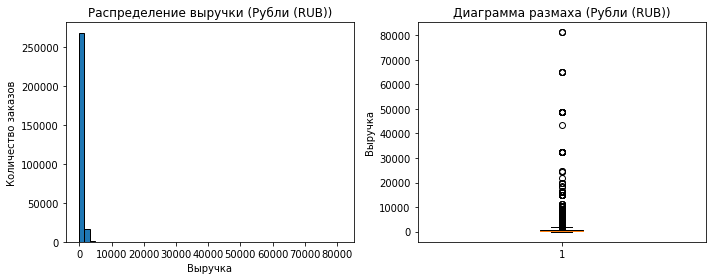


Тенге (KZT):
Минимальная выручка: 0.00
Максимальная выручка: 26425.86
Средняя выручка: 4995.21
Медианная выручка: 3698.83
Стандартное отклонение: 4916.75


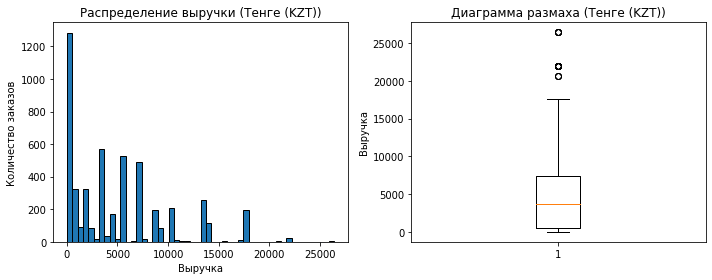

In [13]:
print("\nАнализ выручки (revenue):")

# Функция для анализа выручки в конкретной валюте
def analyze_revenue(df, currency_name):
    print(f"\n{currency_name}:")
    print(f"Минимальная выручка: {df['revenue'].min():.2f}")
    print(f"Максимальная выручка: {df['revenue'].max():.2f}")
    print(f"Средняя выручка: {df['revenue'].mean():.2f}")
    print(f"Медианная выручка: {df['revenue'].median():.2f}")
    print(f"Стандартное отклонение: {df['revenue'].std():.2f}")
    
    # Гистограмма распределения
    plt.figure(figsize=(10, 4))
    plt.subplot(1, 2, 1)
    plt.hist(df['revenue'], bins=50, edgecolor='black')
    plt.title(f'Распределение выручки ({currency_name})')
    plt.xlabel('Выручка')
    plt.ylabel('Количество заказов')
    
    # Диаграмма размаха (boxplot) для визуализации выбросов
    plt.subplot(1, 2, 2)
    plt.boxplot(df['revenue'])
    plt.title(f'Диаграмма размаха ({currency_name})')
    plt.ylabel('Выручка')
    
    plt.tight_layout()
    plt.show()

# Анализируем для каждой валюты
analyze_revenue(df_rub, 'Рубли (RUB)')
analyze_revenue(df_kzt, 'Тенге (KZT)')

In [14]:
# Фильтруем данные по 99-му процентилю для каждой валюты
threshold_rub = df_rub['revenue'].quantile(0.99)
threshold_kzt = df_kzt['revenue'].quantile(0.99)

print(f"Порог для RUB: {threshold_rub:.2f}")
print(f"Порог для KZT: {threshold_kzt:.2f}")

df_rub_filtered = df_rub[df_rub['revenue'] <= threshold_rub].copy()
df_kzt_filtered = df_kzt[df_kzt['revenue'] <= threshold_kzt].copy()

print(f"\nПосле фильтрации:")
print(f"Заказов в RUB осталось: {len(df_rub_filtered)} (было {len(df_rub)})")
print(f"Заказов в KZT осталось: {len(df_kzt_filtered)} (было {len(df_kzt)})")

Порог для RUB: 2570.80
Порог для KZT: 17617.24

После фильтрации:
Заказов в RUB осталось: 282742 (было 285542)
Заказов в KZT осталось: 5040 (было 5069)


Общая статистика по всему датасету:
Минимальное количество билетов: 1
Максимальное количество билетов: 57
Среднее количество билетов: 2.75
Медианное количество билетов: 3.00

Распределение количества билетов в заказе:
1     41798
2     83807
3     92247
4     54812
5     13476
6      4283
7        62
8        21
9        38
10       19
11       13
12        4
13        7
14        4
15        2
17        6
19        5
27        2
30        2
37        1
Name: tickets_count, dtype: int64


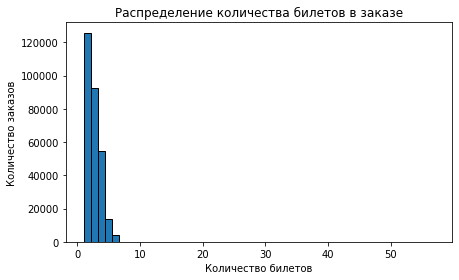

In [15]:
# Анализируем количество билетов (tickets_count) для всего датасета

print("Общая статистика по всему датасету:")
print(f"Минимальное количество билетов: {df_merged['tickets_count'].min()}")
print(f"Максимальное количество билетов: {df_merged['tickets_count'].max()}")
print(f"Среднее количество билетов: {df_merged['tickets_count'].mean():.2f}")
print(f"Медианное количество билетов: {df_merged['tickets_count'].median():.2f}")

# Выведем распределение
print("\nРаспределение количества билетов в заказе:")
print(df_merged['tickets_count'].value_counts().sort_index().head(20))

# Гистограмма
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.hist(df_merged['tickets_count'], bins=50, edgecolor='black')
plt.title('Распределение количества билетов в заказе')
plt.xlabel('Количество билетов')
plt.ylabel('Количество заказов')

plt.tight_layout()
plt.show()

In [16]:
# Объединяем отфильтрованные данные
df_filtered = pd.concat([df_rub_filtered, df_kzt_filtered], ignore_index=True)

print(f"\nИтоговый размер датасета после очистки: {len(df_filtered)} строк")
print(f"Удалено строк: {len(df_merged) - len(df_filtered)}")


Итоговый размер датасета после очистки: 287782 строк
Удалено строк: 2829


In [17]:
# Проверяем данные на полные дубликаты
duplicates = df_filtered[df_filtered.duplicated()]
print(f"Полных дубликатов: {len(duplicates)}")

Полных дубликатов: 0


In [18]:
# Проверяем данные на неявные дубликаты
duplicates_df = df_filtered[df_filtered.duplicated(subset=['user_id','created_ts_msk','event_id', 'venue_id'], keep='first')]

In [19]:
# Удаляем неявные дубликаты
duplicates_df.drop_duplicates()

,order_id,user_id,created_dt_msk,created_ts_msk,event_id,cinema_circuit,age_limit,currency_code,device_type_canonical,revenue,...,event_name_code,event_type_description,event_type_main,organizers,region_name,city_name,city_id,venue_id,venue_name,venue_address
3431,6885906,0e6fa925c5f346f,2024-09-09,2024-09-09 11:00:15,534657,нет,16,rub,mobile,1018.82,...,dff567b7-11a5-4c4c-b223-70c8ab7efd15,концерт,концерты,№1134,Ветренский регион,Кокжар,20,2866,"Школа фотографии ""Золотое"" Инк","ш. Микрорайон, д. 79 стр. 50"
3826,7299678,a0384c26d91e09e,2024-08-24,2024-08-24 00:07:14,534657,нет,16,rub,mobile,679.21,...,dff567b7-11a5-4c4c-b223-70c8ab7efd15,концерт,концерты,№1134,Ветренский регион,Кокжар,20,2866,"Школа фотографии ""Золотое"" Инк","ш. Микрорайон, д. 79 стр. 50"
8873,7927528,c7a762e320f0def,2024-06-19,2024-06-19 11:07:59,538926,нет,18,rub,mobile,0.00,...,7b378eca-5d03-4f42-9491-a32887424226,событие,другое,№4549,Каменевский регион,Глиногорск,213,3474,"Креативное пространство ""Вдох"" Лимитед","бул. Пригородный, д. 7/1"
14668,8015659,86dd447fed39a50,2024-09-30,2024-09-30 12:42:22,521167,нет,12,rub,desktop,125.12,...,76f2781c-7a60-415a-8905-b7932f8512d0,событие,выставки,№5023,Каменевский регион,Глиногорск,213,3240,"Народный ансамбль ""Дизайн"" Инкорпорэйтед","пер. Речной, д. 5/9"
28156,1905243,b54dd0cd81121fc,2024-09-14,2024-09-14 18:28:53,459395,нет,6,rub,mobile,507.58,...,d87326fe-3683-4a22-9288-15cbe7e3026c,концерт,концерты,№4001,Ветренский регион,Кокжар,20,3268,"Международный художественный центр ""Победа"" Лтд","бул. Мелиоративный, д. 1/9 к. 3"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
269244,7113266,5d952114f33c5c6,2024-07-17,2024-07-17 13:37:06,540172,нет,0,rub,mobile,933.64,...,0a8408ea-451a-4c7f-83be-d7224aea3bd8,событие,выставки,№985,Североярская область,Озёрск,2,4333,"Гастрольный театр ""Солнце"" Лтд","пр. Снежный, д. 78 стр. 98"
276742,2507399,964cec52a578685,2024-06-10,2024-06-10 12:14:04,524318,нет,6,rub,desktop,1353.94,...,b529bb72-d776-4aad-a9a0-2c4cbc57b0b6,концерт,концерты,№2955,Каменевский регион,Глиногорск,213,2640,"Культурный центр ""Общие"" Лимитед","ул. Курганная, д. 5"
283108,161502,110125b4a429b43,2024-06-12,2024-06-12 10:23:35,536826,нет,12,kzt,mobile,17617.24,...,76af4f88-c554-4e9e-9df4-1cc8aeec8959,концерт,концерты,№4950,Верхоречная область,Серебрянка,163,2066,"Архитектурное бюро ""Секрет"" Инк","пер. Проточный, д. 70 к. 881"
284811,3320211,ae8e3d5af3036a6,2024-07-30,2024-07-30 11:20:46,533803,нет,16,kzt,mobile,1849.41,...,0686ac7b-6f3e-4177-bb73-16b54acd1223,фестиваль,концерты,№4950,Шанырский регион,Широковка,162,3407,"Арт-кафе ""Речка"" Лимитед","алл. Путейская, д. 548 стр. 7"


In [20]:
# Дальше работаем с df_filtered
df_filtered.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 287782 entries, 0 to 287781
Data columns (total 24 columns):
 #   Column                  Non-Null Count   Dtype         
---  ------                  --------------   -----         
 0   order_id                287782 non-null  int64         
 1   user_id                 287782 non-null  object        
 2   created_dt_msk          287782 non-null  datetime64[ns]
 3   created_ts_msk          287782 non-null  datetime64[ns]
 4   event_id                287782 non-null  int64         
 5   cinema_circuit          287782 non-null  object        
 6   age_limit               287782 non-null  int64         
 7   currency_code           287782 non-null  object        
 8   device_type_canonical   287782 non-null  object        
 9   revenue                 287782 non-null  float64       
 10  service_name            287782 non-null  object        
 11  tickets_count           287782 non-null  int64         
 12  total                   287782

In [21]:
# Для краткости переминуем третий датасет df_final_tickets_tenge на exchange_df и загрузим данные

exchange_df = pd.read_csv('https://code.s3.yandex.net/datasets/final_tickets_tenge_df.csv')
exchange_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 357 entries, 0 to 356
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   data     357 non-null    object 
 1   nominal  357 non-null    int64  
 2   curs     357 non-null    float64
 3   cdx      357 non-null    object 
dtypes: float64(1), int64(1), object(2)
memory usage: 11.3+ KB


In [22]:
# Меняем тип данных стоблца "data"
exchange_df['data'] = pd.to_datetime(exchange_df['data'], format='%Y-%m-%d', errors='coerce')

In [23]:
# Создаем колонку только с датой (без времени) для объединения
exchange_df['date_only'] = exchange_df['data'].dt.date
df_filtered['date_only'] = df_filtered['created_dt_msk'].dt.date

# Объединяем по дате
df_merged = pd.merge(df_filtered, exchange_df[['date_only', 'curs']], 
                     on='date_only', how='left')

# Конвертируем в рубли
df_merged['revenue_rub'] = df_merged.apply(
    lambda x: x['revenue'] if x['currency_code'] == 'RUB' 
    else x['revenue'] * (x['curs'] / 100 if pd.notna(x['curs']) else 0.18),
    axis=1
)

# Удаляем временные колонки
df_filtered = df_merged.drop(['date_only', 'curs'], axis=1)

# Добавляем требуемые столбцы
df_filtered['one_ticket_revenue_rub'] = df_filtered['revenue_rub'] / df_filtered['tickets_count']
df_filtered['month'] = df_filtered['created_dt_msk'].dt.month
df_filtered['season'] = df_filtered['month'].map({
    12: 'зима', 1: 'зима', 2: 'зима',
    3: 'весна', 4: 'весна', 5: 'весна',
    6: 'лето', 7: 'лето', 8: 'лето',
    9: 'осень', 10: 'осень', 11: 'осень'
})

#### Промежуточный вывод

Для анализа выручки разделили данные по валютам: rub и kzt. Количество заказов в рублях: 285542
Количество заказов в тенге: 5069. Проверили данные на выбросы, в столбце revenue обнаружены экстремальные значения. Отфильтровали данные по 99-му процентилю, убрали 1% данных с экстремальными значениями.После фильтрации:
Заказов в RUB осталось: 282742 (было 285542)
Заказов в KZT осталось: 5040 (было 5069). Проверили данные на явные и неявные дубликаты. Было удалено 119 дубликатов.
Объединили отфтльтрованные данные из двух датасетов: orders и events в один датасет df_filtered. Итоговый размер датасета после очистки: 287782 строк
Удалено строк: 2829

Третий датасет df_final_tickets_tenge перименовали на exchange_df. Изменили тип данных столбца "data" на тип данных datetime. Для анализа сконвертировали всю выручку в рубли, по курсу на конкретную дату заказа.

### Исследовательский анализ данных

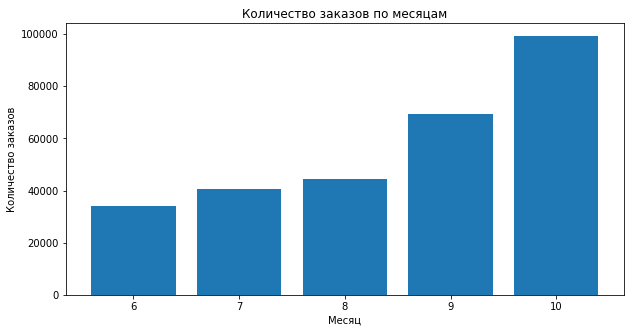

In [24]:
# Считаем количество заказов для каждого месяца

monthly_orders = df_filtered.groupby('month')['order_id'].nunique().reset_index()
monthly_orders = monthly_orders.sort_values('month')

plt.figure(figsize=(10, 5))
plt.bar(monthly_orders['month'], monthly_orders['order_id'])
plt.title('Количество заказов по месяцам')
plt.xlabel('Месяц')
plt.ylabel('Количество заказов')
plt.show()

In [25]:
# Проверяем рост заказов от июня к ноябрю (у нас есть данные с 1 июня по 31 октября)

june = monthly_orders[monthly_orders['month'] == 6]['order_id'].values[0]
october = monthly_orders[monthly_orders['month'] == 10]['order_id'].values[0]
print("Рост заказов от июня к ноябрю (до 31.10.2024г.)")
print(f'Июнь: {june}, Октябрь: {october}, Рост: {((october-june)/june*100):.1f}%')

Рост заказов от июня к ноябрю (до 31.10.2024г.)
Июнь: 34171, Октябрь: 99291, Рост: 190.6%


In [26]:
summer_months = [6, 7, 8]
autumn_months = [9, 10, 11]

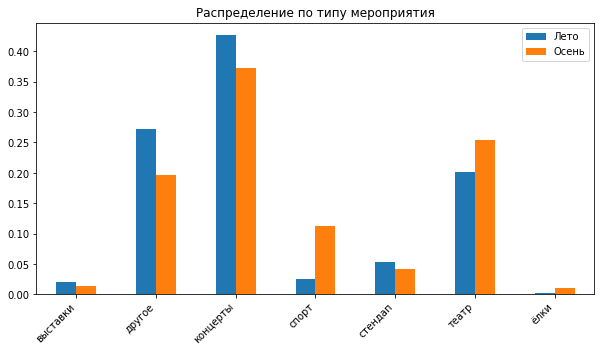

In [27]:
# Распределение заказов по типу мероприятия

summer_events = df_filtered[df_filtered['month'].isin(summer_months)]
autumn_events = df_filtered[df_filtered['month'].isin(autumn_months)]

event_summer = summer_events['event_type_main'].value_counts(normalize=True)
event_autumn = autumn_events['event_type_main'].value_counts(normalize=True)

event_comparison = pd.DataFrame({'Лето': event_summer, 'Осень': event_autumn})
event_comparison.plot(kind='bar', figsize=(10, 5))
plt.xticks(rotation=45, ha='right')
plt.title('Распределение по типу мероприятия')
plt.show()

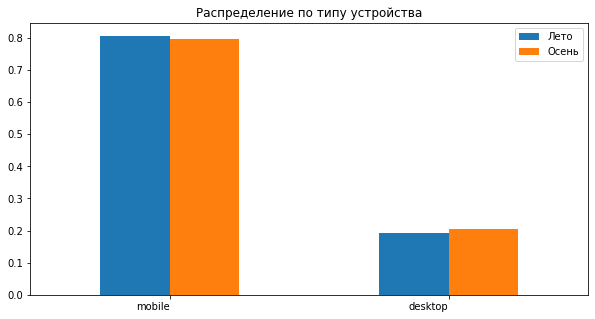

In [28]:
# Распределение заказов по типу устройства

device_summer = summer_events['device_type_canonical'].value_counts(normalize=True)
device_autumn = autumn_events['device_type_canonical'].value_counts(normalize=True)

device_comparison = pd.DataFrame({'Лето': device_summer, 'Осень': device_autumn})
device_comparison.plot(kind='bar', figsize=(10, 5))
plt.xticks(rotation=0, ha='right')
plt.title('Распределение по типу устройства')
plt.show()

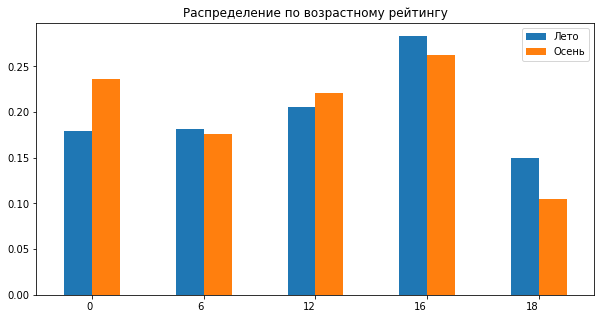

In [29]:
# Распределение заказов по возрастному рейтингу

age_summer = summer_events['age_limit'].value_counts(normalize=True)
age_autumn = autumn_events['age_limit'].value_counts(normalize=True)

age_comparison = pd.DataFrame({'Лето': age_summer, 'Осень': age_autumn})
age_comparison.plot(kind='bar', figsize=(10, 5))
plt.xticks(rotation=0, ha='right')
plt.title('Распределение по возрастному рейтингу')
plt.show()

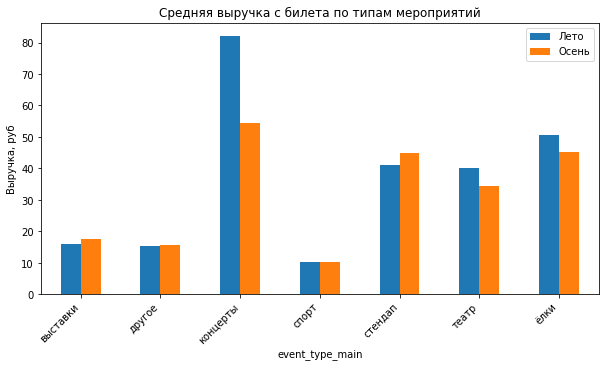

Средняя выручка с билета летом
event_type_main
выставки    16.153077
другое      15.375387
концерты    82.213493
спорт       10.322944
стендап     40.976791
театр       40.188818
ёлки        50.630258
Name: one_ticket_revenue_rub, dtype: float64
Средняя выручка с билета осенью
event_type_main
выставки    17.737232
другое      15.661989
концерты    54.393524
спорт       10.439516
стендап     45.005873
театр       34.301731
ёлки        45.202505
Name: one_ticket_revenue_rub, dtype: float64
                 Изменение, %
event_type_main              
стендап              9.832595
выставки             9.807140
другое               1.864032
спорт                1.129258
ёлки               -10.720374
театр              -14.648569
концерты           -33.838690


In [30]:
# Изменение выручки с билета по типам мероприятий

# Средняя выручка с билета летом
price_summer = summer_events.groupby('event_type_main')['one_ticket_revenue_rub'].mean()

# Средняя выручка с билета осенью
price_autumn = autumn_events.groupby('event_type_main')['one_ticket_revenue_rub'].mean()

price_comparison = pd.DataFrame({'Лето': price_summer, 'Осень': price_autumn})
price_comparison.plot(kind='bar', figsize=(10, 5))
plt.xticks(rotation=45, ha='right')
plt.title('Средняя выручка с билета по типам мероприятий')
plt.ylabel('Выручка, руб')
plt.show()

print('Средняя выручка с билета летом')
print(price_summer)
print('Средняя выручка с билета осенью')
print(price_autumn)

# Относительное изменение
price_comparison['Изменение, %'] = ((price_comparison['Осень'] - price_comparison['Лето']) / price_comparison['Лето'] * 100)
print(price_comparison[['Изменение, %']].sort_values('Изменение, %', ascending=False))

#### Промежуточный вывод


Средняя выручка с билета летом:

- выставки    16.153077
- другое      15.375387
- концерты    82.213493
- спорт       10.322944
- стендап     40.976791
- театр       40.188818
- ёлки        50.630258

Средняя выручка с билета осенью:

- выставки    17.737232
- другое      15.661989
- концерты    54.393524
- спорт       10.439516
- стендап     45.005873
- театр       34.301731
- ёлки        45.202505

Изменение от июня к ноябрю в %:

             
- стендап              9.832595
- выставки             9.807140
- другое               1.864032
- спорт                1.129258
- ёлки               -10.720374
- театр              -14.648569
- концерты           -33.838690

В осенние месяцы (9, 10) наблюдается снижение спроса на елки, театр и концерты. В тоже время, спрос на елки рос в августе, что может быть связано с ранним бронированием новогодних мероприятий.
Рост спроса почти на 10% в категориях стендап и выставки от июня к ноябрю. В тоже время, доля этих мероприятий в общей структуре невелика.

In [31]:
# Фильтруем данные только за сентябрь и октябрь
autumn_data = df_filtered[df_filtered['month'].isin([9, 10])].copy()

# Создаем сводную таблицу по дням
daily_stats = autumn_data.groupby(autumn_data['created_dt_msk'].dt.date).agg(
    total_orders=('order_id', 'nunique'),
    dau=('user_id', 'nunique'),
    avg_ticket_price=('one_ticket_revenue_rub', 'mean')
).reset_index()

# Переименовываем колонку с датой
daily_stats = daily_stats.rename(columns={'created_dt_msk': 'date'})

# Рассчитываем средние показатели
daily_stats['orders_per_user'] = daily_stats['total_orders'] / daily_stats['dau']
daily_stats

,date,total_orders,dau,avg_ticket_price,orders_per_user
0,2024-09-01,1327,564,38.424085,2.352837
1,2024-09-02,1380,574,39.598477,2.404181
2,2024-09-03,5113,778,16.031655,6.571979
3,2024-09-04,1773,686,37.355426,2.584548
4,2024-09-05,1944,739,39.679928,2.630582
...,...,...,...,...,...
56,2024-10-27,2849,1034,37.621908,2.755319
57,2024-10-28,2839,985,34.381016,2.882234
58,2024-10-29,2836,998,36.091616,2.841683
59,2024-10-30,2928,1039,38.070107,2.818094


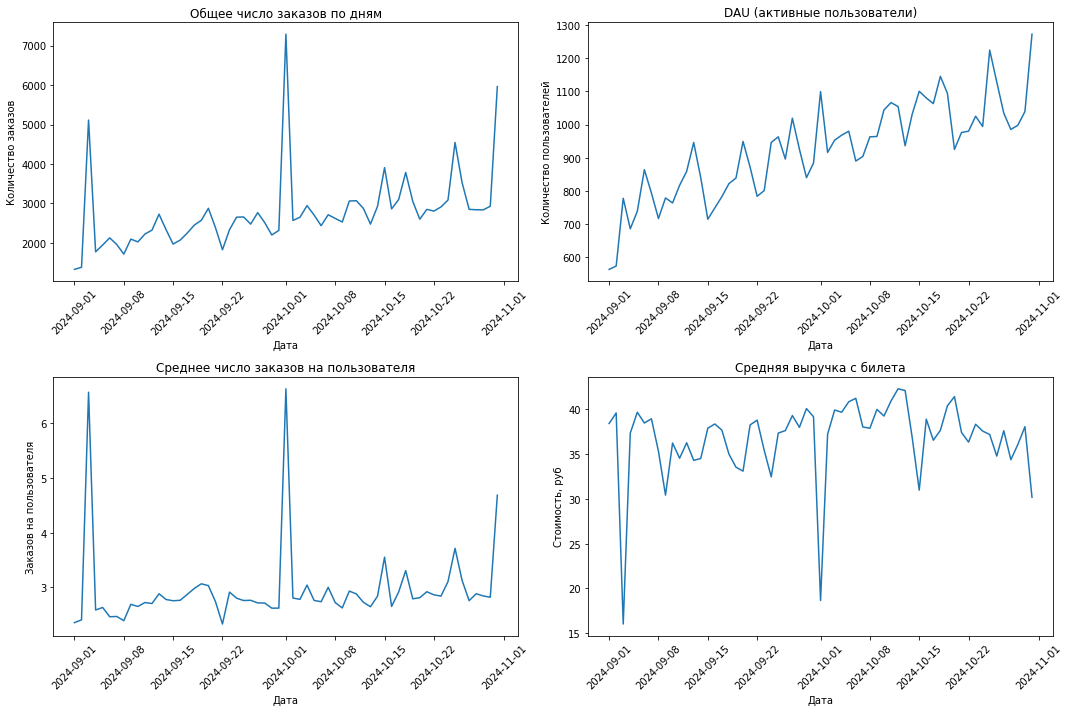

In [32]:
#  Визуализмруем динамику по дням
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Общее число заказов
axes[0, 0].plot(daily_stats['date'], daily_stats['total_orders'])
axes[0, 0].set_title('Общее число заказов по дням')
axes[0, 0].set_xlabel('Дата')
axes[0, 0].set_ylabel('Количество заказов')
axes[0, 0].tick_params(axis='x', rotation=45)

# DAU
axes[0, 1].plot(daily_stats['date'], daily_stats['dau'])
axes[0, 1].set_title('DAU (активные пользователи)')
axes[0, 1].set_xlabel('Дата')
axes[0, 1].set_ylabel('Количество пользователей')
axes[0, 1].tick_params(axis='x', rotation=45)

# Среднее число заказов на пользователя
axes[1, 0].plot(daily_stats['date'], daily_stats['orders_per_user'])
axes[1, 0].set_title('Среднее число заказов на пользователя')
axes[1, 0].set_xlabel('Дата')
axes[1, 0].set_ylabel('Заказов на пользователя')
axes[1, 0].tick_params(axis='x', rotation=45)

# Средняя стоимость билета
axes[1, 1].plot(daily_stats['date'], daily_stats['avg_ticket_price'])
axes[1, 1].set_title('Средняя выручка с билета')
axes[1, 1].set_xlabel('Дата')
axes[1, 1].set_ylabel('Стоимость, руб')
axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [33]:
# Смотрим недельную цикличность
# Добавляем день недели к daily_stats
daily_stats['date'] = pd.to_datetime(daily_stats['date'])
daily_stats['day_of_week'] = daily_stats['date'].dt.day_name()

# Группируем по дням недели
weekday_stats = daily_stats.groupby('day_of_week').agg({
    'total_orders': 'mean',
    'dau': 'mean',
    'orders_per_user': 'mean',
    'avg_ticket_price': 'mean'
}).reset_index()

# Порядок дней недели
days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
weekday_stats['day_of_week'] = pd.Categorical(weekday_stats['day_of_week'], categories=days_order, ordered=True)
weekday_stats = weekday_stats.sort_values('day_of_week')

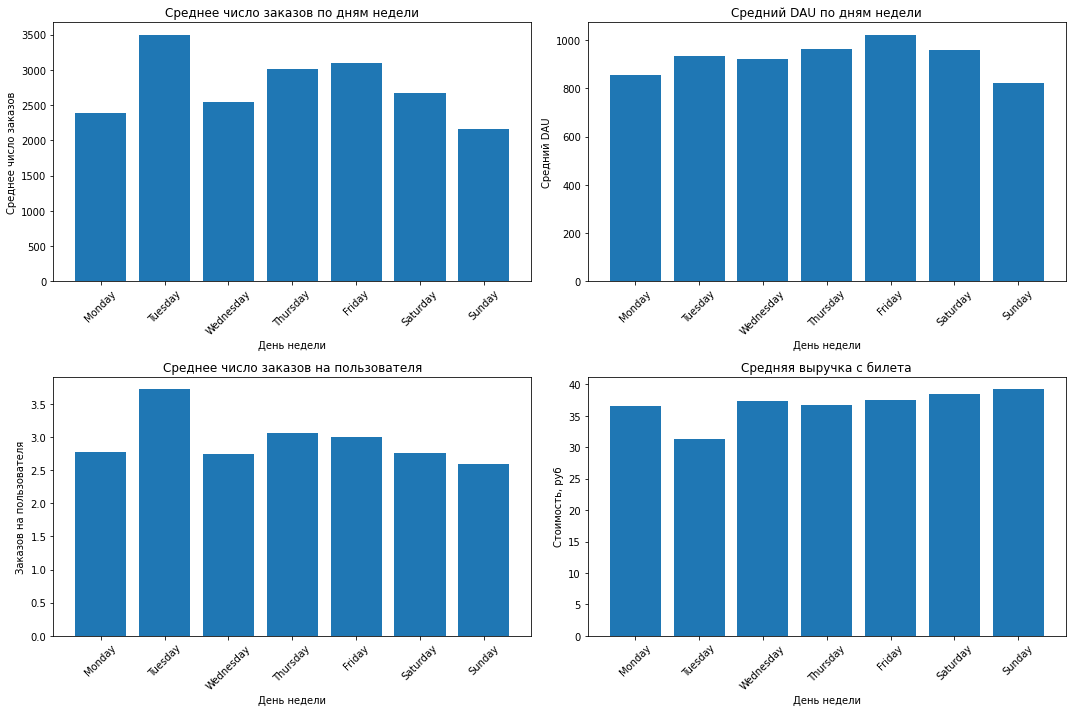

In [34]:
# Визуализация по дням недели
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Среднее число заказов
axes[0, 0].bar(weekday_stats['day_of_week'], weekday_stats['total_orders'])
axes[0, 0].set_title('Среднее число заказов по дням недели')
axes[0, 0].set_xlabel('День недели')
axes[0, 0].set_ylabel('Среднее число заказов')
axes[0, 0].tick_params(axis='x', rotation=45)

# Средний DAU
axes[0, 1].bar(weekday_stats['day_of_week'], weekday_stats['dau'])
axes[0, 1].set_title('Средний DAU по дням недели')
axes[0, 1].set_xlabel('День недели')
axes[0, 1].set_ylabel('Средний DAU')
axes[0, 1].tick_params(axis='x', rotation=45)

# Среднее число заказов на пользователя
axes[1, 0].bar(weekday_stats['day_of_week'], weekday_stats['orders_per_user'])
axes[1, 0].set_title('Среднее число заказов на пользователя')
axes[1, 0].set_xlabel('День недели')
axes[1, 0].set_ylabel('Заказов на пользователя')
axes[1, 0].tick_params(axis='x', rotation=45)

# Средняя выручка с билета
axes[1, 1].bar(weekday_stats['day_of_week'], weekday_stats['avg_ticket_price'])
axes[1, 1].set_title('Средняя выручка с билета')
axes[1, 1].set_xlabel('День недели')
axes[1, 1].set_ylabel('Стоимость, руб')
axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [35]:
# Сравнениваем будни и выходные
# Определяем будни и выходные
weekdays = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday']
weekends = ['Saturday', 'Sunday']

daily_stats['is_weekend'] = daily_stats['day_of_week'].isin(weekends)

# Группируем по будням/выходным
weekend_comparison = daily_stats.groupby('is_weekend').agg({
    'total_orders': 'mean',
    'dau': 'mean',
    'orders_per_user': 'mean',
    'avg_ticket_price': 'mean'
}).reset_index()

weekend_comparison['is_weekend'] = weekend_comparison['is_weekend'].map({True: 'Выходные', False: 'Будни'})

print("Сравнение будни/выходные:")
print(weekend_comparison)

Сравнение будни/выходные:
  is_weekend  total_orders         dau  orders_per_user  avg_ticket_price
0      Будни   2907.022727  937.409091         3.066034         35.916202
1   Выходные   2396.294118  887.823529         2.675402         38.882597


 #### Промежуточный вывод
 
Неделя  с 22.09. по 01.10 отличается всплеском общим количеством заказов, ростом среднего числа заказов на одного пользователя и снижением выручки с каждого заказа. На 1-е сентября аналогичные аномалии. Вероятно, в эти дни проходила акция или сервис Яндекс.Афиша делал скидки на билеты за счет среза своей маржи.

Недельная цикличность. Больше всего заказов делают во вторник, меньше всего заказов - в воскресенье. В тоже время, во вторник самая низкая выручка с каждого заказа.
На буднях заказывают больше чем в выходные дни (2907 заказов против 2396). Среднее количество активных пользователей на буднях выше, чем в выходные (937 чел. против 887). Среднее количество заказов на одного пользователя в будни 3.066 против 2.675. Но! Выручка с билета (в среднем) ниже, чем с заказов на выходных (35.916 против 38.882 руб.)


Топ-10 регионов по количеству мероприятий:
             region_name  unique_events  events_share  total_orders  \
23    Каменевский регион           5935     26.544121         89674   
60  Североярская область           3800     16.995393         43745   
77   Широковская область           1232      5.510085         16169   
57  Светополянский округ           1075      4.807907          7503   
52   Речиновская область            702      3.139675          6267   
74      Травяная область            683      3.054698          5036   
11  Горицветская область            551      2.464332          5153   
61  Серебринская область            541      2.419607          5586   
78   Яблоневская область            535      2.392772          6125   
69  Тепляковская область            528      2.361465          4385   

    orders_share  
23     31.160392  
60     15.200742  
77      5.618489  
57      2.607182  
52      2.177690  
74      1.749936  
11      1.790591  
61      1.941053  
78  

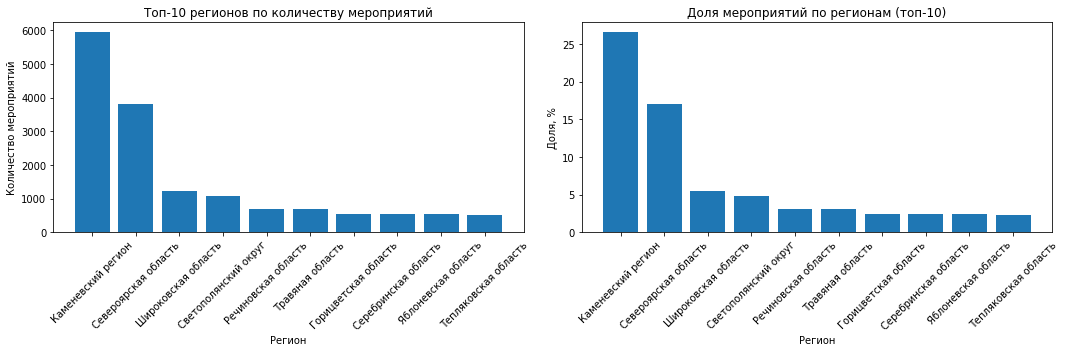

In [36]:
# Анализируем выручку по регионам

region_stats = df_filtered.groupby('region_name').agg(
    unique_events=('event_id', 'nunique'),
    total_orders=('order_id', 'nunique'),
    total_revenue=('revenue_rub', 'sum')
).reset_index()

# Считаем доли
region_stats['events_share'] = region_stats['unique_events'] / region_stats['unique_events'].sum() * 100
region_stats['orders_share'] = region_stats['total_orders'] / region_stats['total_orders'].sum() * 100
region_stats['revenue_share'] = region_stats['total_revenue'] / region_stats['total_revenue'].sum() * 100

# Сортируем по количеству мероприятий
region_stats_sorted = region_stats.sort_values('unique_events', ascending=False)

print("Топ-10 регионов по количеству мероприятий:")
print(region_stats_sorted[['region_name', 'unique_events', 'events_share', 'total_orders', 'orders_share']].head(10))

# Визуализация
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# 1. Топ-10 регионов по количеству мероприятий
top_regions = region_stats_sorted.head(10)
axes[0].bar(top_regions['region_name'], top_regions['unique_events'])
axes[0].set_title('Топ-10 регионов по количеству мероприятий')
axes[0].set_xlabel('Регион')
axes[0].set_ylabel('Количество мероприятий')
axes[0].tick_params(axis='x', rotation=45)

# 2. Доля мероприятий по регионам (топ-10)
axes[1].bar(top_regions['region_name'], top_regions['events_share'])
axes[1].set_title('Доля мероприятий по регионам (топ-10)')
axes[1].set_xlabel('Регион')
axes[1].set_ylabel('Доля, %')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [37]:
# Анализируем выручку по партнерам (service_name)
partner_stats = df_filtered.groupby('service_name').agg(
    unique_events=('event_id', 'nunique'),
    total_orders=('order_id', 'nunique'),
    total_revenue=('revenue_rub', 'sum'),
    avg_ticket_price=('one_ticket_revenue_rub', 'mean')
).reset_index()

# Считаем доли
partner_stats['events_share'] = partner_stats['unique_events'] / partner_stats['unique_events'].sum() * 100
partner_stats['orders_share'] = partner_stats['total_orders'] / partner_stats['total_orders'].sum() * 100
partner_stats['revenue_share'] = partner_stats['total_revenue'] / partner_stats['total_revenue'].sum() * 100

# Сортируем по выручке
partner_stats_sorted = partner_stats.sort_values('total_revenue', ascending=False)

print("\nТоп-10 партнеров по выручке:")
print(partner_stats_sorted[['service_name', 'unique_events', 'total_orders', 'total_revenue', 'revenue_share']].head(10))


Топ-10 партнеров по выручке:
          service_name  unique_events  total_orders  total_revenue  \
24           Мой билет           1300         34443   7.669257e+06   
3   Билеты без проблем           4247         62871   5.074882e+06   
25             Облачко           2335         26402   3.560848e+06   
21         Лови билет!           4867         40806   3.206010e+06   
8       Весь в билетах            855         16425   3.169498e+06   
5        Билеты в руки           3530         40286   2.526440e+06   
19        Край билетов            252          6109   1.218890e+06   
26           Прачечная           1026         10222   9.087200e+05   
13        Дом культуры            272          4412   8.263795e+05   
35              Яблоко            714          5004   7.479398e+05   

    revenue_share  
24      23.578290  
3       15.602167  
25      10.947437  
21       9.856527  
8        9.744275  
5        7.767262  
19       3.747342  
26       2.793760  
13       2.540613  

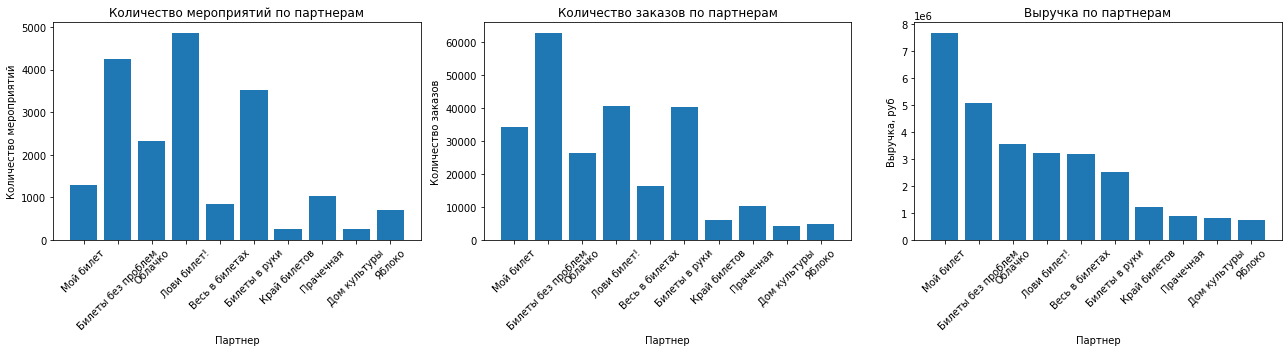

In [38]:
# Визуализация по партнерам
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Количество мероприятий по партнерам (топ-10)
top_partners = partner_stats_sorted.head(10)
axes[0].bar(top_partners['service_name'], top_partners['unique_events'])
axes[0].set_title('Количество мероприятий по партнерам')
axes[0].set_xlabel('Партнер')
axes[0].set_ylabel('Количество мероприятий')
axes[0].tick_params(axis='x', rotation=45)

# 2. Количество заказов по партнерам (топ-10)
axes[1].bar(top_partners['service_name'], top_partners['total_orders'])
axes[1].set_title('Количество заказов по партнерам')
axes[1].set_xlabel('Партнер')
axes[1].set_ylabel('Количество заказов')
axes[1].tick_params(axis='x', rotation=45)

# 3. Выручка по партнерам (топ-10)
axes[2].bar(top_partners['service_name'], top_partners['total_revenue'])
axes[2].set_title('Выручка по партнерам')
axes[2].set_xlabel('Партнер')
axes[2].set_ylabel('Выручка, руб')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [39]:
# Анализ концентрации
print("\nАНАЛИЗ КОНЦЕНТРАЦИИ")

# Для регионов
top3_regions_events = region_stats_sorted.head(3)['events_share'].sum()
top5_regions_events = region_stats_sorted.head(5)['events_share'].sum()
top3_regions_revenue = region_stats_sorted.head(3)['revenue_share'].sum()
top5_regions_revenue = region_stats_sorted.head(5)['revenue_share'].sum()

print(f"Доля мероприятий в топ-3 регионах: {top3_regions_events:.1f}%")
print(f"Доля мероприятий в топ-5 регионах: {top5_regions_events:.1f}%")
print(f"Доля выручки в топ-3 регионах: {top3_regions_revenue:.1f}%")
print(f"Доля выручки в топ-5 регионах: {top5_regions_revenue:.1f}%")

# Для партнеров
top3_partners_orders = partner_stats_sorted.head(3)['orders_share'].sum()
top5_partners_orders = partner_stats_sorted.head(5)['orders_share'].sum()
top3_partners_revenue = partner_stats_sorted.head(3)['revenue_share'].sum()
top5_partners_revenue = partner_stats_sorted.head(5)['revenue_share'].sum()

print(f"\nДоля заказов у топ-3 партнеров: {top3_partners_orders:.1f}%")
print(f"Доля заказов у топ-5 партнеров: {top5_partners_orders:.1f}%")
print(f"Доля выручки у топ-3 партнеров: {top3_partners_revenue:.1f}%")
print(f"Доля выручки у топ-5 партнеров: {top5_partners_revenue:.1f}%")


АНАЛИЗ КОНЦЕНТРАЦИИ
Доля мероприятий в топ-3 регионах: 49.0%
Доля мероприятий в топ-5 регионах: 57.0%
Доля выручки в топ-3 регионах: 51.0%
Доля выручки в топ-5 регионах: 54.4%

Доля заказов у топ-3 партнеров: 43.0%
Доля заказов у топ-5 партнеров: 62.9%
Доля выручки у топ-3 партнеров: 50.1%
Доля выручки у топ-5 партнеров: 69.7%


#### Промежуточный вывод

Больше всего мероприятий проведено в Каменевском районе - 5935 (31% от всех мероприятий) и в Североярской области - 3800 (15% от всех мероприятий)
Самую большую выручку принес партнер «Мой билет». Самое большое количество заказов у партнера «Билеты без проблем». Самое большое количество мероприятий у партнера «Лови билет»

### Статистический анализ данных 

Проверяем две гипотезы:

- Среднее количество заказов на одного пользователя мобильного приложения выше по сравнению с пользователями стационарных устройств.
- Среднее время между заказами пользователей мобильных приложений выше по сравнению с пользователями стационарных устройств.

Гипотеза 1: Среднее количество заказов на пользователя
Мобильные: 2.858
Стационарные: 1.972
t-тест: p-value = 0.0000

Гипотеза 2: Среднее время между заказами
Мобильные: 13.786 дней
Стационарные: 18.097 дней
t-тест: p-value = 0.0000


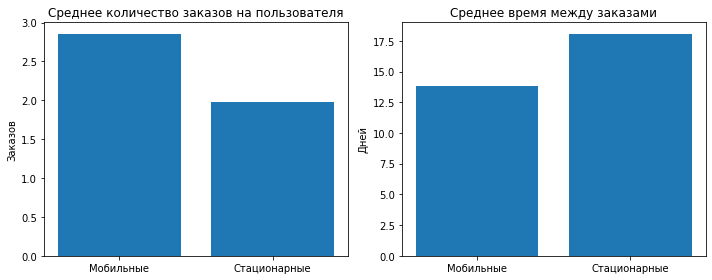


Вывод:
1. Гипотеза 1 (больше заказов на мобильных): Подтверждается
2. Гипотеза 2 (больше время между заказами на мобильных): Не подтверждается


In [40]:
# Используем осенние данные
autumn_data = df_filtered[df_filtered['month'].isin([9, 10])]

# Находим пользователей, которые использовали оба типа устройств
mobile_users = set(autumn_data[autumn_data['device_type_canonical'] == 'mobile']['user_id'].unique())
desktop_users = set(autumn_data[autumn_data['device_type_canonical'] != 'mobile']['user_id'].unique())

# Пользователи, которые есть в обеих группах
common_users = mobile_users.intersection(desktop_users)

# Удаляем этих пользователей из анализа
clean_data = autumn_data[~autumn_data['user_id'].isin(common_users)]

# Разделяем на чистые группы
mobile = clean_data[clean_data['device_type_canonical'] == 'mobile']
desktop = clean_data[clean_data['device_type_canonical'] != 'mobile']

# Гипотеза 1: Среднее количество заказов на пользователя
mobile_orders = mobile.groupby('user_id')['order_id'].nunique()
desktop_orders = desktop.groupby('user_id')['order_id'].nunique()

print("Гипотеза 1: Среднее количество заказов на пользователя")
print(f"Мобильные: {mobile_orders.mean():.3f}")
print(f"Стационарные: {desktop_orders.mean():.3f}")

# Тест для гипотезы 1
from scipy import stats
t_stat1, p_value1 = stats.ttest_ind(mobile_orders, desktop_orders)
print(f"t-тест: p-value = {p_value1:.4f}")

# Гипотеза 2: Среднее время между заказами
mobile_days = mobile['days_since_prev'].dropna()
desktop_days = desktop['days_since_prev'].dropna()
print("\nГипотеза 2: Среднее время между заказами")
print(f"Мобильные: {mobile_days.mean():.3f} дней")
print(f"Стационарные: {desktop_days.mean():.3f} дней")

# Тест для гипотезы 2
t_stat2, p_value2 = stats.ttest_ind(mobile_days, desktop_days)
print(f"t-тест: p-value = {p_value2:.4f}")

# Визуализация
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# График 1
axes[0].bar(['Мобильные', 'Стационарные'], [mobile_orders.mean(), desktop_orders.mean()])
axes[0].set_title('Среднее количество заказов на пользователя')
axes[0].set_ylabel('Заказов')

# График 2
axes[1].bar(['Мобильные', 'Стационарные'], [mobile_days.mean(), desktop_days.mean()])
axes[1].set_title('Среднее время между заказами')
axes[1].set_ylabel('Дней')

plt.tight_layout()
plt.show()

# Вывод
print("\nВывод:")
print(f"1. Гипотеза 1 (больше заказов на мобильных): {'Подтверждается' if mobile_orders.mean() > desktop_orders.mean() else 'Не подтверждается'}")
print(f"2. Гипотеза 2 (больше время между заказами на мобильных): {'Подтверждается' if mobile_days.mean() > desktop_days.mean() else 'Не подтверждается'}")

## Итоги

Для анализа были использованы данные:

Первый датасет final_tickets_orders_df.csv включает информацию обо всех заказах билетов, совершённых с двух типов устройств — мобильных и стационарных. Поля датасета соответствуют таблице purchases, с которой вы работали в предыдущих заданиях:

order_id — уникальный идентификатор заказа.
user_id — уникальный идентификатор пользователя.
created_dt_msk — дата создания заказа (московское время).
created_ts_msk — дата и время создания заказа (московское время).
event_id — идентификатор мероприятия из таблицы events.
cinema_circuit — сеть кинотеатров. Если не применимо, то здесь будет значение 'нет'.
age_limit — возрастное ограничение мероприятия.
currency_code — валюта оплаты, например rub для российских рублей.
device_type_canonical — тип устройства, с которого был оформлен заказ, например mobile для мобильных устройств, desktop для стационарных.
revenue — выручка от заказа.
service_name — название билетного оператора.
tickets_count — количество купленных билетов.
total — общая сумма заказа. В данные также добавлен столбец days_since_prev с количеством дней с предыдущей покупки для каждого пользователя. Если покупки не было, то данные содержат пропуск.
Второй датасет final_tickets_events_df содержит информацию о событиях, включая город и регион события, а также информацию о площадке проведения мероприятия. Датасет содержит такие поля:

event_id — уникальный идентификатор мероприятия.
event_name — название мероприятия. Аналог поля event_name_code из исходной базы данных.
event_type_description — описание типа мероприятия.
event_type_main — основной тип мероприятия: театральная постановка, концерт и так далее.
organizers — организаторы мероприятия.
region_name — название региона.
city_name — название города.
venue_id — уникальный идентификатор площадки.
venue_name — название площадки.
venue_address — адрес площадки.
Третий датасет final_tickets_tenge_df.csv с информацией о курсе тенге к российскому рублю за 2024 год. Значения в рублях представлено для 100 тенге. Датасет содержит такие поля:

nominal — номинал (100 тенге).
data — дата.
curs — курс тенге к рублю.
cdx — обозначение валюты (kzt).


## Общий вывод

- Наблюдается последовательный рост количества заказов от июня к ноябрю (до 31.10.2024г.) Самое большое количество заказов в октябре (более 9 тыс.)
Июнь: 34171, Октябрь: 99291, Рост: 190.6% . 

- Разделим исследование на два сезона: лето (6, 7, 8 месяцы) и осень (9, 10 месяцы). В разрезе мероприятий самые популярные за весь период данных - концерты. Летом спрос на билеты выше, чем осенью. В осенние месяцы растет спрос на театр. Доля таких категорий как выставки, спортивные мероприятия и стендап сильно ниже, чем концерты и театр. Тем не менее, осенью спрос на спортивные мероприятия выше в 3 раза.

- Больше всего заказов через мобильные устройства (mobile), но разница в днях между заказами у mobile незначительно выше, чем у десктопной версии.

- Больше всего заказов делают в возрастной категории 16+, затем 12+ .

- Динамика выручки от летних месяцев (6, 7, 8 к осенним  (9, 10) в разрезе категорий мероприятий:
Средняя выручка с билета летом:

выставки 16.153077
другое 15.375387
концерты 82.213493
спорт 10.322944
стендап 40.976791
театр 40.188818
ёлки 50.630258
Средняя выручка с билета осенью:

выставки 17.737232
другое 15.661989
концерты 54.393524
спорт 10.439516
стендап 45.005873
театр 34.301731
ёлки 45.202505
Изменение от июня к ноябрю в %:

стендап 9.832595
выставки 9.807140
другое 1.864032
спорт 1.129258
ёлки -10.720374
театр -14.648569
концерты -33.838690

- Создана сводная таблица по дням на два осенних месяца (с недельной группировкой). Неделя  с 22.09. по 01.10 отличается всплеском общим количеством заказов, ростом среднего числа заказов на одного пользователя и снижением выручки с каждого заказа. На 1-е сентября аналогичные аномалии. Вероятно, в эти дни проходила акция или сервис Яндекс.Афиша делал скидки на билеты за счет среза своей маржи.

- Недельная цикличность. Больше всего заказов делают во вторник, меньше всего заказов - в воскресенье. В тоже время, во вторник самая низкая выручка с каждого заказа.
На буднях заказывают больше чем в выходные дни (2907 заказов против 2396). Среднее количество активных пользователей на буднях выше, чем в выходные (937 чел. против 887). Среднее количество заказов на одного пользователя в будни 3.066 против 2.675. Но! Выручка с билета (в среднем) ниже, чем с заказов на выходных (35.916 против 38.882 руб.)

- Больше всего мероприятий проведено в Каменевском районе - 5935 (31% от всех мероприятий) и в Североярской области - 3800 (15% от всех мероприятий)

- Самую большую выручку принес партнер «Мой билет». Самое большое количество заказов у партнера «Билеты без проблем». Самое большое количество мероприятий у партнера «Лови билет».

СТАТИСТИЧЕСКИЙ АНАЛИЗ ДАННЫХ

- Провели две гипотезы:
Гипотеза 1 (больше заказов совершается с мобильных устройств): подтверждается
Гипотеза 2 (время между заказами больше для мобильных устройств): подтверждается.

### Рекомендации

Основной фокус на сильных категориях: концерты и театры. Летом увеличивать маркетинговую активность в отношении концертов, осенью - театры. Несмотря на невысокий общий спрос на спортивные мероприятия, осенью рост в 3 раза. Возможно, разные портнерства и коллаборации со спортивными клубами/агентами в осенний период будут эффективны. 

Нужно дополнительно проанаизировать падение средней выручки м билета на концерты осенью (-33,8%). Были проведены акции или продавались более дешевые билеты? Можно попробовать разные форматы, например более дорогие билеты/премиум.

В сентябре (1 числа и 24.09-02.10) были аномалии с всплеском продаж билетов и одновременно снижением выручки. Возможно проводились какие-то акции, если да - посчитать ROI этих акций, а также проанализировать время проведения.

Анализ по дням недели показал, что больше всего заказов во вторник, но более низкий средний чек. Нужно понять почему и найти способ увеличить средний чек. На выходных меньше заказов - увеличить рассылку и напоминания о горячих предложениях. 

Большинство заказов совершается с мобильных устройств - удостовериться, что совершить заказ легко, возможно убрать лишние шаги и улучшить интерфейс. 

Самую большую выручку приносит партнер " Мой билет" - изучить партнера и углубить отношения.

Регионы: сконцентрировать маркетинговый бюджет на сильных регионах (Каменевский район и Североярская область), но также искать потенциально интересные районы для расширения географического присутствия. Для этих целей в анализе представлен ТОП-10 регионов.
